In [49]:
# ============================================================
# NOTEBOOK 1 - Imports
# ============================================================
from pathlib import Path
import copy
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py

from scipy.signal import find_peaks

import OrcFxAPI


In [50]:
# ============================================================
# NOTEBOOK 2 - Paden en experimentdefinitie
# ============================================================
data_root = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_data\01_Rawdata")
orca_root = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA")


exp_paths = {
    "spring": {
        "pitch": [
            data_root / "02" / "002" /  "34224_03CB_02_002_001_01_Decay1.h5m",
            data_root / "02" / "002" / "34224_03CB_02_002_001_01_Decay2.h5m",
            data_root / "02" / "002" / "34224_03CB_02_002_001_01_Decay3.h5m",
        ],
        "roll": [
            data_root / "02" / "002" /  "34224_03CB_02_002_003_01_Decay1.h5m",
            data_root / "02" / "002" /  "34224_03CB_02_002_003_01_Decay2.h5m",
            data_root / "02" / "002" /  "34224_03CB_02_002_004_01_Decay1.h5m",
            data_root / "02" / "002" /  "34224_03CB_02_002_004_01_Decay2.h5m",
        ],
        "heave": [
            data_root / "02" / "002" /  "34224_03CB_02_002_006_01_Decay1.h5m",
            data_root / "02" / "002" /  "34224_03CB_02_002_006_01_Decay2.h5m",
            data_root / "02" / "002" / "34224_03CB_02_002_007_01_Decay1.h5m",
            data_root / "02" / "002" /  "34224_03CB_02_002_008_01_Decay1.h5m",
        ],
    },

    "fixedwith": {
        "pitch": [
            data_root / "02" / "003" / "34224_03CB_02_003_001_01_Decay1.h5m",
            data_root / "02" / "003" /"34224_03CB_02_003_002_01_Decay1.h5m",
            data_root / "02" / "003" /  "34224_03CB_02_003_003_01_Decay1.h5m",
        ],
        "roll": [
            data_root / "02" / "003" /  "34224_03CB_02_003_004_01_Decay1.h5m",
            data_root / "02" / "003" /  "34224_03CB_02_003_005_01_Decay1.h5m",
            data_root / "02" / "003" /  "34224_03CB_02_003_006_01_Decay1.h5m",
        ],
        "heave": [
            data_root / "02" / "003" /  "34224_03CB_02_003_007_01_Decay1.h5m",
            data_root / "02" / "003" / "34224_03CB_02_003_008_01_Decay1.h5m",
            data_root / "02" / "003" / "34224_03CB_02_003_009_01_Decay1.h5m",
            data_root / "02" / "003" / "34224_03CB_02_003_010_01_Decay1.h5m",
        ],
    },

    "fixedwithout": {
        "pitch": [
            data_root / "02" / "004" / "34224_03CB_02_004_001_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_002_01_Decay1.h5m",
            data_root / "02" / "004" /"34224_03CB_02_004_003_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_004_01_Decay1.h5m",
        ],
        "roll": [
            data_root / "02" / "004" /  "34224_03CB_02_004_005_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_006_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_007_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_008_01_Decay1.h5m",
            
        ],
        "heave": [
            data_root / "02" / "004" / "34224_03CB_02_004_009_01_Decay1.h5m",
            data_root / "02" / "004" /  "34224_03CB_02_004_010_01_Decay1.h5m",
            data_root / "02" / "004" /  "34224_03CB_02_004_011_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_012_01_Decay1.h5m",
        ],
    }
}


exp_paths = {
    "spring": {
        "pitch": [
            data_root / "02" / "002" /  "34224_03CB_02_002_001_01_Decay1.h5m",
        ],
    },

    "fixedwith": {
        "roll": [
            data_root / "02" / "003" / "34224_03CB_02_003_004_01_Decay1.h5m",
        ],
    },

    "fixedwithout": {
        "heave": [
            data_root / "02" / "004" / "34224_03CB_02_004_010_01_Decay1.h5m",
        ],
    }
}

# exp_paths = {
#     "spring": {
#         "pitch": [
#             data_root / "02" / "002" /  "34224_03CB_02_002_001_01_Decay3.h5m",
#         ],
#     },
# }

# OrcaFlex modelbestanden
model_map = {
    "spring": {
        "40s": orca_root / "Harlequin_spring_40s.dat",
        "120s": orca_root / "Harlequin_spring_120s.dat",
    },
    "fixedwith": {
        "40s": orca_root / "Harlequin_fixed_40s.dat",
        "120s": orca_root / "Harlequin_fixed_120s.dat",
    },
    "fixedwithout": {
        "40s": orca_root / "Harlequin_fixed_40s.dat",
        "120s": orca_root / "Harlequin_fixed_120s.dat",
    }
}

# Signalen in h5m
signal_map = {
    "pitch": "UnfilteredSignals/PITCH (unfiltered)",
    "roll": "UnfilteredSignals/ROLL (unfiltered)",
    "heave": "UnfilteredSignals/Z_COG (unfiltered)"
}

time_signal_map = {
    "pitch": "UnfilteredSignals/time",
    "roll": "UnfilteredSignals/time",
    "heave": "UnfilteredSignals/time"
}

# Simulatieduur per DOF
sim_duration_map = {
    "pitch": 120.0,
    "roll": 120.0,
    "heave": 40.0
}


In [51]:
# ============================================================
# NOTEBOOK 3 - Instellingen calibratie
# ============================================================
vesselname = "floaters"
vesseltypename = "floatertype"  # pas aan indien nodig

# decay start detectie
lookback_window = 1
quiet_window_end = 12.0
quiet_window_length = 50.0

# minima voor initiële amplitude
min_initial_amp = {
    "pitch": 3.0,
    "roll": 3.0,
    "heave": 1,   # pas aan indien nodig
}

# peak detectie
prominence_map = {
    "pitch": 0.2,
    "roll": 0.2,
    "heave": 0.002,
}

# zoekruimte
coarse_lin_values_rot = np.linspace(0, 1000, 7)
coarse_quad_values_rot  = np.linspace(0, 1000, 7)

mid_delta_lin_rot = 300
mid_delta_quad_rot = 300
mid_num_lin_rot = 7
mid_num_quad_rot = 7

fine_delta_lin_rot = 50
fine_delta_quad_rot = 50
fine_num_lin_rot = 6
fine_num_quad_rot = 6


coarse_lin_values_rot = np.linspace(300, 300, 1)
coarse_quad_values_rot  = np.linspace(300, 300, 1)

mid_delta_lin_rot = 300
mid_delta_quad_rot = 300
mid_num_lin_rot = 1
mid_num_quad_rot = 1

fine_delta_lin_rot = 50
fine_delta_quad_rot = 50
fine_num_lin_rot = 1
fine_num_quad_rot = 1


coarse_lin_values_heave = np.linspace(0, 15, 7)
coarse_quad_values_heave = np.linspace(0, 15, 7)

mid_delta_lin_heave = 5
mid_delta_quad_heave = 5
mid_num_lin_heave = 7
mid_num_quad_heave = 7

fine_delta_lin_heave = 1
fine_delta_quad_heave = 1
fine_num_lin_heave = 5
fine_num_quad_heave = 5

# output
output_dir = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

plots_dir = output_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

excel_path = output_dir / "calibrated_decay_coefficients.xlsx"


In [52]:

# ============================================================
# NOTEBOOK 4 - Helper functies experimentdata
# ============================================================
def read_decay_signals(exp_path: Path, dof: str):
    filtered_map = {
        "pitch": "FittedSignals/PITCH decay fit",
        "roll": "FittedSignals/ROLL decay fit",
        "heave": "FittedSignals/Z_COG decay fit",
    }

    unfiltered_map = {
        "pitch": "UnfilteredSignals/PITCH (unfiltered)",
        "roll": "UnfilteredSignals/ROLL (unfiltered)",
        "heave": "UnfilteredSignals/Z_COG (unfiltered)",
    }

    with h5py.File(exp_path, "r") as f:
        t_filt = np.array(f["CroppedSignals/time"])
        z_filt = np.array(f[filtered_map[dof]])

        t = np.array(f["UnfilteredSignals/time"])
        z = np.array(f[unfiltered_map[dof]])

    return t_filt, z_filt, t, z

def find_first_zero_crossing(t, z):
    z = np.asarray(z)

    for i in range(1, len(z)):
        if z[i - 1] == 0:
            return i - 1, t[i - 1]
        if z[i - 1] * z[i] < 0:
            return i, t[i]

    raise ValueError("Geen zero crossing gevonden.")

def detect_decay_start(t, z, lookback_window=5.0, quiet_window_end=12.0, quiet_window_length=50.0):
    """
    Detecteer decay start als eerste tijdstip waarop het signaal duidelijk
    afwijkt van een rustige periode ervoor.
    """
    t = np.asarray(t)
    z = np.asarray(z)

    quiet_end_time = t[-1] - quiet_window_end
    quiet_start_time = quiet_end_time - quiet_window_length

    quiet_mask = (t >= quiet_start_time) & (t <= quiet_end_time)
    if np.sum(quiet_mask) < 10:
        raise ValueError("Rustige periode te klein om decay start te bepalen.")

    z_quiet = z[quiet_mask]
    mu = np.mean(z_quiet)
    sigma = np.std(z_quiet)
    threshold = max(sigma, 1e-6)

    idx_start = None
    for i in range(len(t)):
        if t[i] < t[0] + lookback_window:
            continue
        if abs(z[i] - mu) > threshold:
            idx_start = i
            break

    if idx_start is None:
        idx_start = np.argmax(np.abs(z - mu))

    return idx_start, t[idx_start], mu, sigma

def find_initial_amplitude_from_zero_crossing(t, z, t_zero, search_window=20.0):
    mask = (t >= t_zero - search_window) & (t <= t_zero)

    if np.sum(mask) == 0:
        raise ValueError("Geen data gevonden in zoekvenster voor initiële amplitude.")

    t_win = t[mask]
    z_win = z[mask]

    i_local = np.argmax(np.abs(z_win))
    return t_win[i_local], z_win[i_local]

def classify_extremum_type(a_value):
    return "peak" if a_value >= 0 else "trough"

def find_next_same_type_extremum(t, z, t_reference, extremum_type, prominence):
    t = np.asarray(t)
    z = np.asarray(z)

    if extremum_type == "peak":
        idx_all, _ = find_peaks(z, prominence=prominence)
    elif extremum_type == "trough":
        idx_all, _ = find_peaks(-z, prominence=prominence)
    else:
        raise ValueError(f"Onbekend extremum_type: {extremum_type}")

    if len(idx_all) == 0:
        raise ValueError(f"Geen {extremum_type}s gevonden in signaal.")

    times_all = t[idx_all]

    # Zoek eerst het extremum dat hoort bij de release / aangegeven amplitude.
    ref_pos = int(np.argmin(np.abs(times_all - t_reference)))
    if abs(times_all[ref_pos] - t_reference) > 8.0:
        raise ValueError(
            f"Geen {extremum_type} dicht genoeg bij release gevonden "
            f"(verschil = {abs(times_all[ref_pos] - t_reference):.3f} s)."
        )

    next_pos = ref_pos + 1
    if next_pos >= len(idx_all):
        raise ValueError(f"Geen volgende {extremum_type} gevonden na de release.")

    idx_next = idx_all[next_pos]
    return {
        "idx_release": int(idx_all[ref_pos]),
        "t_release": float(t[idx_all[ref_pos]]),
        "a_release": float(z[idx_all[ref_pos]]),
        "idx_next": int(idx_next),
        "t_next": float(t[idx_next]),
        "a_next": float(z[idx_next]),
        "type": extremum_type,
    }

def prepare_experiment(exp_path: Path, dof: str):
    t_filt, z_filt, t, z = read_decay_signals(exp_path, dof)

    idx_zero, t_zero = find_first_zero_crossing(t_filt, z_filt)

    t_release_guess, a_release_guess = find_initial_amplitude_from_zero_crossing(
        t, z, t_zero, search_window=20.0
    )

    if abs(a_release_guess) < min_initial_amp[dof]:
        raise ValueError(
            f"Initiële amplitude te klein voor {dof}: {a_release_guess:.4f} "
            f"(minimum {min_initial_amp[dof]:.4f})"
        )

    extremum_type = classify_extremum_type(a_release_guess)
    ext_info = find_next_same_type_extremum(
        t=t,
        z=z,
        t_reference=t_release_guess,
        extremum_type=extremum_type,
        prominence=prominence_map[dof],
    )

    mask_decay = t >= ext_info["t_next"]
    t_decay = t[mask_decay] - ext_info["t_next"]
    z_decay = z[mask_decay]

    # Volledige experimentsignaal, relatief aan de simulatiestart
    # (dus de tweede piek/dal van hetzelfde type ligt op t = 0).
    t_full_rel = t - ext_info["t_next"]

    return {
        "exp_path": exp_path,
        "dof": dof,
        "t_filtered": t_filt,
        "z_filtered": z_filt,
        "t_full": t,
        "z_full": z,
        "t_full_rel": t_full_rel,
        "t_zero": t_zero,
        "t_release": ext_info["t_release"],
        "a_release": ext_info["a_release"],
        "t_init": ext_info["t_next"],
        "a_init": ext_info["a_next"],
        "extremum_type": extremum_type,
        "t_decay": t_decay,
        "z_decay": z_decay,
    }


In [53]:
# ============================================================
# NOTEBOOK 5 - Helper functies extrema en score
# ============================================================
def get_peaks_and_troughs(t, z, prominence):
    peaks, _ = find_peaks(z, prominence=prominence)
    troughs, _ = find_peaks(-z, prominence=prominence)

    return {
        "peak_idx": peaks,
        "trough_idx": troughs,
        "t_peaks": t[peaks],
        "z_peaks": z[peaks],
        "t_troughs": t[troughs],
        "z_troughs": z[troughs],
    }

def match_extrema_by_order(z_ref, z_sim):
    n = min(len(z_ref), len(z_sim))
    if n == 0:
        return np.array([]), np.array([])
    return np.asarray(z_ref[:n]), np.asarray(z_sim[:n])

def compute_nrmse(z_ref, z_sim):
    z_ref = np.asarray(z_ref)
    z_sim = np.asarray(z_sim)

    if len(z_ref) == 0 or len(z_sim) == 0:
        return np.nan

    scale = max(np.mean(np.abs(z_ref)), 1e-9)
    return np.sqrt(np.mean(((z_sim - z_ref) / scale) ** 2))

def compute_score_from_extrema(exp_extrema, sim_extrema):
    z_ref_peaks, z_sim_peaks = match_extrema_by_order(exp_extrema["z_peaks"], sim_extrema["z_peaks"])
    z_ref_troughs, z_sim_troughs = match_extrema_by_order(exp_extrema["z_troughs"], sim_extrema["z_troughs"])

    nrmse_peaks = compute_nrmse(z_ref_peaks, z_sim_peaks)
    nrmse_troughs = compute_nrmse(z_ref_troughs, z_sim_troughs)

    vals = [v for v in [nrmse_peaks, nrmse_troughs] if np.isfinite(v)]
    score = np.mean(vals) if len(vals) > 0 else np.inf

    return score, nrmse_peaks, nrmse_troughs, len(z_ref_peaks), len(z_ref_troughs)


In [54]:
# ============================================================
# NOTEBOOK 6 - Helper functies OrcaFlex
# ============================================================
def get_model_path(construction: str, dof: str) -> Path:
    sim_key = "120s" if dof in ["pitch", "roll"] else "40s"
    return model_map[construction][sim_key]

def get_grid_settings(dof: str):
    dof = dof.lower()

    if dof in ["pitch", "roll"]:
        return {
            "coarse_lin": coarse_lin_values_rot,
            "coarse_quad": coarse_quad_values_rot,
            "mid_delta_lin": mid_delta_lin_rot,
            "mid_delta_quad": mid_delta_quad_rot,
            "mid_num_lin": mid_num_lin_rot,
            "mid_num_quad": mid_num_quad_rot,
            "fine_delta_lin": fine_delta_lin_rot,
            "fine_delta_quad": fine_delta_quad_rot,
            "fine_num_lin": fine_num_lin_rot,
            "fine_num_quad": fine_num_quad_rot,
        }

    elif dof == "heave":
        return {
            "coarse_lin": coarse_lin_values_heave,
            "coarse_quad": coarse_quad_values_heave,
            "mid_delta_lin": mid_delta_lin_heave,
            "mid_delta_quad": mid_delta_quad_heave,
            "mid_num_lin": mid_num_lin_heave,
            "mid_num_quad": mid_num_quad_heave,
            "fine_delta_lin": fine_delta_lin_heave,
            "fine_delta_quad": fine_delta_quad_heave,
            "fine_num_lin": fine_num_lin_heave,
            "fine_num_quad": fine_num_quad_heave,
        }

    else:
        raise ValueError(f"Onbekende DOF: {dof}")

def set_initial_amplitude(vessel, dof: str, amplitude: float):
    """
    Zet alleen de juiste DOF op initiële amplitude, de rest op 0.
    """
    vessel.InitialX = 0.0
    vessel.InitialY = 0.0
    vessel.InitialZ = 0.0
    vessel.InitialHeel = 0.0
    vessel.InitialTrim = 0.0
    vessel.InitialHeading = 0.0

    if dof == "pitch":
        vessel.InitialTrim = float(amplitude)
    elif dof == "roll":
        vessel.InitialHeel = float(amplitude)
    elif dof == "heave":
        vessel.InitialZ = float(amplitude)
    else:
        raise ValueError(f"Onbekende DOF: {dof}")

def set_damping(vesseltype, dof: str, lin_coeff: float, quad_coeff: float):
    """
    Pas dit blok eventueel aan naar jouw exacte OrcaFlex-veldnamen.
    """
    dof = dof.lower()

    if dof == "pitch":
        # voorbeeldnamen - controleren in jouw model/API
        vesseltype.OtherDampingLinearCoeffRy = lin_coeff
        vesseltype.OtherDampingQuadraticCoeffRy = quad_coeff

    elif dof == "roll":
        vesseltype.OtherDampingLinearCoeffRx = lin_coeff
        vesseltype.OtherDampingQuadraticCoeffRx = quad_coeff

    elif dof == "heave":
        vesseltype.OtherDampingLinearCoeffz = lin_coeff
        vesseltype.OtherDampingQuadraticCoeffz = quad_coeff

    else:
        raise ValueError(f"Onbekende DOF: {dof}")

def run_orcaflex_decay(model_path: Path, dof: str, initial_amplitude: float, lin_coeff: float, quad_coeff: float):
    """
    Draai OrcaFlex simulatie en lees de juiste output DOF uit.
    """
    model = OrcFxAPI.Model(str(model_path))
    vessel = model[vesselname]
    vesseltype = model[vesseltypename]

    set_initial_amplitude(vessel, dof, initial_amplitude)
    set_damping(vesseltype, dof, lin_coeff, quad_coeff)

    # sim_duration = sim_duration_map[dof]
    # model.general.StageDuration[0] = 0.0
    # model.general.StageDuration[1] = sim_duration

    model.RunSimulation()

    # period = OrcFxAPI.SpecifiedPeriod(OrcFxAPI.pnWholeSimulation)
    if dof == "pitch":
        t = np.asarray(model.general.TimeHistory("Time"), dtype=float)
        z = np.asarray(vessel.TimeHistory("Rotation 2"), dtype=float)
    elif dof == "roll":
        t = np.asarray(model.general.TimeHistory("Time"), dtype=float)
        z = np.asarray(vessel.TimeHistory("Rotation 1"), dtype=float)
    elif dof == "heave":
        t = np.asarray(model.general.TimeHistory("Time"), dtype=float)
        z = np.asarray(vessel.TimeHistory("Z"), dtype=float)
    else:
        raise ValueError(f"Onbekende DOF: {dof}")

    return t, z



In [55]:
# ============================================================
# NOTEBOOK 7 - Zoekroosters
# ============================================================

def build_mid_grid(best_lin, best_quad, dof: str):
    grid = get_grid_settings(dof)

    lin_vals = np.linspace(
        best_lin - grid["mid_delta_lin"],
        best_lin + grid["mid_delta_lin"],
        grid["mid_num_lin"]
    )
    quad_vals = np.linspace(
        best_quad - grid["mid_delta_quad"],
        best_quad + grid["mid_delta_quad"],
        grid["mid_num_quad"]
    )

    lin_vals = np.clip(lin_vals, 0, None)
    quad_vals = np.clip(quad_vals, 0, None)
    return lin_vals, quad_vals


def build_fine_grid(best_lin, best_quad, dof: str):
    grid = get_grid_settings(dof)

    lin_vals = np.linspace(
        best_lin - grid["fine_delta_lin"],
        best_lin + grid["fine_delta_lin"],
        grid["fine_num_lin"]
    )
    quad_vals = np.linspace(
        best_quad - grid["fine_delta_quad"],
        best_quad + grid["fine_delta_quad"],
        grid["fine_num_quad"]
    )

    lin_vals = np.clip(lin_vals, 0, None)
    quad_vals = np.clip(quad_vals, 0, None)
    return lin_vals, quad_vals

In [56]:

# ============================================================
# NOTEBOOK 8 - Eén experiment calibreren
# ============================================================
def calibrate_single_experiment(exp_info, construction: str, dof: str, verbose=True):
    model_path = get_model_path(construction, dof)
    prominence = prominence_map[dof]

    exp_extrema = get_peaks_and_troughs(exp_info["t_decay"], exp_info["z_decay"], prominence=prominence)

    best = {
        "score": np.inf,
        "lin": np.nan,
        "quad": np.nan,
        "nrmse_peaks": np.nan,
        "nrmse_troughs": np.nan,
        "t_sim": None,
        "z_sim": None,
        "t_sim_aligned": None,
        "z_sim_aligned": None,
        "sim_release_time": np.nan,
        "sim_release_amp": np.nan,
        "sim_init_time": np.nan,
        "sim_init_amp": np.nan,
    }

    def evaluate_grid(lin_values, quad_values, stage_name):
        nonlocal best

        total = len(lin_values) * len(quad_values)
        count = 0

        for lin in lin_values:
            for quad in quad_values:
                count += 1
                try:
                    t_sim_raw, z_sim_raw = run_orcaflex_decay(
                        model_path=model_path,
                        dof=dof,
                        initial_amplitude=exp_info["a_release"],
                        lin_coeff=float(lin),
                        quad_coeff=float(quad),
                    )

                    sim_start_info = find_next_same_type_extremum(
                        t=t_sim_raw,
                        z=z_sim_raw,
                        t_reference=t_sim_raw[0],
                        extremum_type=exp_info["extremum_type"],
                        prominence=prominence,
                    )

                    mask_sim = t_sim_raw >= sim_start_info["t_next"]
                    t_sim = t_sim_raw[mask_sim] - sim_start_info["t_next"]
                    z_sim = z_sim_raw[mask_sim]

                    sim_extrema = get_peaks_and_troughs(t_sim, z_sim, prominence=prominence)

                    score, nrmse_peaks, nrmse_troughs, n_peaks, n_troughs = compute_score_from_extrema(
                        exp_extrema, sim_extrema
                    )

                    if verbose:
                        print(
                            f"[{stage_name:7s} {count:>3d}/{total}] "
                            f"lin={lin:.4f}, quad={quad:.4f}, score={score:.6f} "
                            f"(peaks={nrmse_peaks:.6f}, troughs={nrmse_troughs:.6f})"
                        )

                    if np.isfinite(score) and score < best["score"]:
                        best = {
                            "score": score,
                            "lin": float(lin),
                            "quad": float(quad),
                            "nrmse_peaks": float(nrmse_peaks),
                            "nrmse_troughs": float(nrmse_troughs),
                            "t_sim": t_sim_raw,
                            "z_sim": z_sim_raw,
                            "t_sim_aligned": t_sim,
                            "z_sim_aligned": z_sim,
                            "sim_release_time": float(sim_start_info["t_release"]),
                            "sim_release_amp": float(sim_start_info["a_release"]),
                            "sim_init_time": float(sim_start_info["t_next"]),
                            "sim_init_amp": float(sim_start_info["a_next"]),
                        }

                except Exception as e:
                    if verbose:
                        print(
                            f"[{stage_name:7s} {count:>3d}/{total}] "
                            f"lin={lin:.4f}, quad={quad:.4f} -> ERROR: {e}"
                        )

    grid = get_grid_settings(dof)

    # coarse
    evaluate_grid(grid["coarse_lin"], grid["coarse_quad"], "coarse")

    # mid
    mid_lin_values, mid_quad_values = build_mid_grid(best["lin"], best["quad"], dof)
    evaluate_grid(mid_lin_values, mid_quad_values, "mid")

    # fine
    fine_lin_values, fine_quad_values = build_fine_grid(best["lin"], best["quad"], dof)
    evaluate_grid(fine_lin_values, fine_quad_values, "fine")

    result = {
        "construction": construction,
        "dof": dof,
        "exp_path": str(exp_info["exp_path"]),
        "t_release": exp_info["t_release"],
        "a_release": exp_info["a_release"],
        "t_init": exp_info["t_init"],
        "a_init": exp_info["a_init"],
        "extremum_type": exp_info["extremum_type"],
        "best_lin": best["lin"],
        "best_quad": best["quad"],
        "best_score": best["score"],
        "best_nrmse_peaks": best["nrmse_peaks"],
        "best_nrmse_troughs": best["nrmse_troughs"],
        "t_exp": exp_info["t_decay"],
        "z_exp": exp_info["z_decay"],
        "t_exp_full": exp_info["t_full"],
        "z_exp_full": exp_info["z_full"],
        "t_exp_full_rel": exp_info["t_full_rel"],
        "t_sim": best["t_sim_aligned"],
        "z_sim": best["z_sim_aligned"],
        "t_sim_raw": best["t_sim"],
        "z_sim_raw": best["z_sim"],
        "sim_release_time": best["sim_release_time"],
        "sim_release_amp": best["sim_release_amp"],
        "sim_init_time": best["sim_init_time"],
        "sim_init_amp": best["sim_init_amp"],
    }
    return result


In [57]:

# ============================================================
# NOTEBOOK 9 - Plotfunctie
# ============================================================
def plot_best_fit(result, save_dir: Path):
    construction = result["construction"]
    dof = result["dof"]
    exp_name = Path(result["exp_path"]).stem

    LABEL_SIZE = 12
    TITLE_SIZE = 14
    TICK_SIZE = 10

    t_exp = result["t_exp"]
    z_exp = result["z_exp"]
    t_exp_full_rel = result["t_exp_full_rel"]
    z_exp_full = result["z_exp_full"]
    t_sim = result["t_sim"]
    z_sim = result["z_sim"]

    if t_sim is None or z_sim is None:
        return

    prominence = prominence_map[dof]
    exp_ext = get_peaks_and_troughs(t_exp, z_exp, prominence=prominence)
    sim_ext = get_peaks_and_troughs(t_sim, z_sim, prominence=prominence)

    dof_dir = save_dir / dof / construction
    dof_dir.mkdir(parents=True, exist_ok=True)

    plt.figure(figsize=(14, 6))

    # Hele experimentsignaal tonen, maar nog steeds uitgelijnd zodat
    # de simulatiestart op t = 0 ligt.
    plt.plot(t_exp_full_rel, z_exp_full, label="Experiment", linewidth=2, color="#1f77b4")
    plt.plot(t_sim, z_sim, label="Best simulation", linewidth=2, color="orange")

    plt.scatter(exp_ext["t_peaks"], exp_ext["z_peaks"], s=50, marker="o", color="#1f77b4")
    plt.scatter(
        exp_ext["t_troughs"], exp_ext["z_troughs"],
        s=50, marker="o", label="Extrema (experiment)", color="#1f77b4"
    )
    plt.scatter(sim_ext["t_peaks"], sim_ext["z_peaks"], s=50, marker="o", color="orange")
    plt.scatter(
        sim_ext["t_troughs"], sim_ext["z_troughs"],
        s=50, marker="o", label="Extrema (simulation)", color="orange"
    )

    # Eerste gedetecteerde initiële amplitude in het experiment
    t_release_rel = result["t_release"] - result["t_init"]
    plt.scatter(
        [t_release_rel], [result["a_release"]],
        s=180, marker="x", linewidths=3, color="#1f77b4",
        label="Initial amplitude (experiment)"
    )

    # Simulatie start na één volledige oscillatie op t = 0
    plt.scatter(
        [0.0], [result["sim_init_amp"]],
        s=180, marker="x", linewidths=3, color="orange",
        label="Initial amplitude (simulation)"
    )

    plt.xlim(t_release_rel - 30, t_sim[-1])
    plt.title(
        f"Type: {construction} - DOF: {dof} - Exp: {exp_name}\n"
        f"Linear={result['best_lin']:.3f}, Quadratic={result['best_quad']:.3f} \n "
        f"NRMSE={result['best_score']:.5f}", fontsize=TITLE_SIZE
    )
    plt.xlabel("Time [s]", fontsize=LABEL_SIZE)
    if dof in ["pitch", "roll"]:
        plt.ylabel(f"{dof.capitalize()} [degrees]", fontsize=LABEL_SIZE)
    else:
        plt.ylabel(f"{dof.capitalize()} [m]", fontsize=LABEL_SIZE)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(dof_dir / f"{dof}_{construction}_{exp_name}.png", dpi=200)
    plt.show()
    plt.close()



START: construction=spring, dof=pitch, n=1

Experiment: 34224_03CB_02_002_001_01_Decay1.h5m
[coarse    1/1] lin=300.0000, quad=300.0000, score=0.052412 (peaks=0.053105, troughs=0.051719)
[mid       1/1] lin=0.0000, quad=0.0000, score=1.461300 (peaks=1.396776, troughs=1.525825)
[fine      1/1] lin=250.0000, quad=250.0000, score=0.103809 (peaks=0.096057, troughs=0.111560)


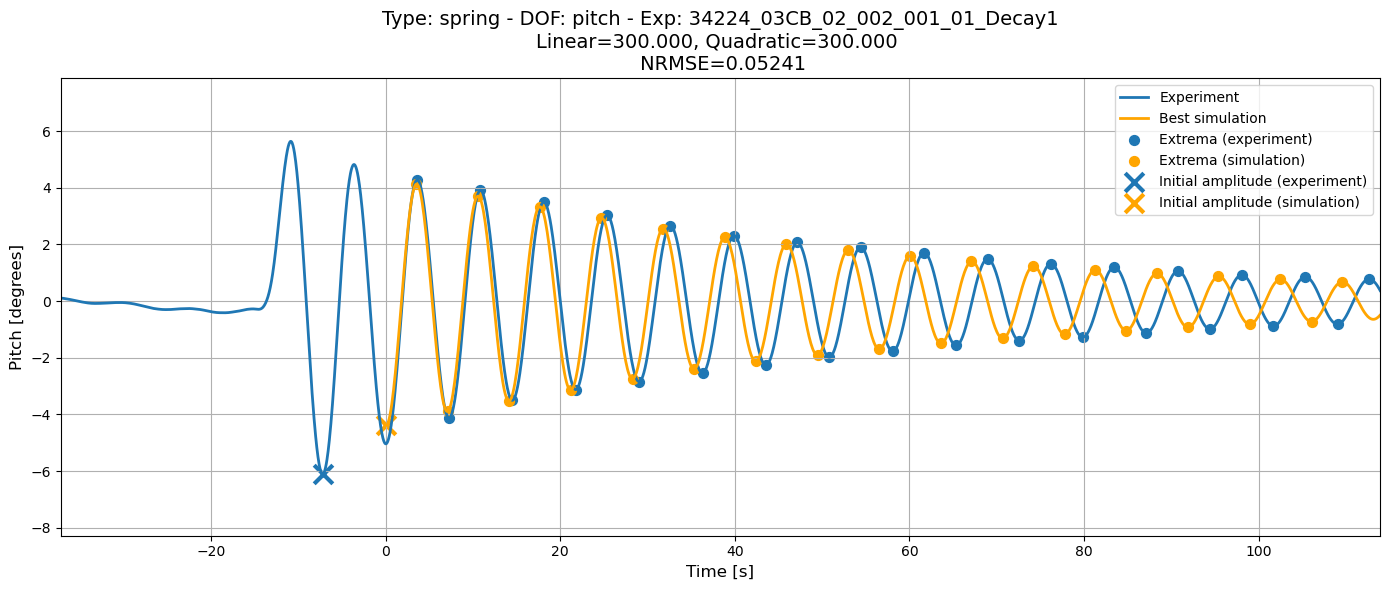

BEST -> lin=300.0000, quad=300.0000, score=0.052412

START: construction=fixedwith, dof=roll, n=1

Experiment: 34224_03CB_02_003_004_01_Decay1.h5m
[coarse    1/1] lin=300.0000, quad=300.0000, score=0.186582 (peaks=0.190487, troughs=0.182678)
[mid       1/1] lin=0.0000, quad=0.0000, score=1.165313 (peaks=1.210352, troughs=1.120274)
[fine      1/1] lin=250.0000, quad=250.0000, score=0.082437 (peaks=0.085272, troughs=0.079601)


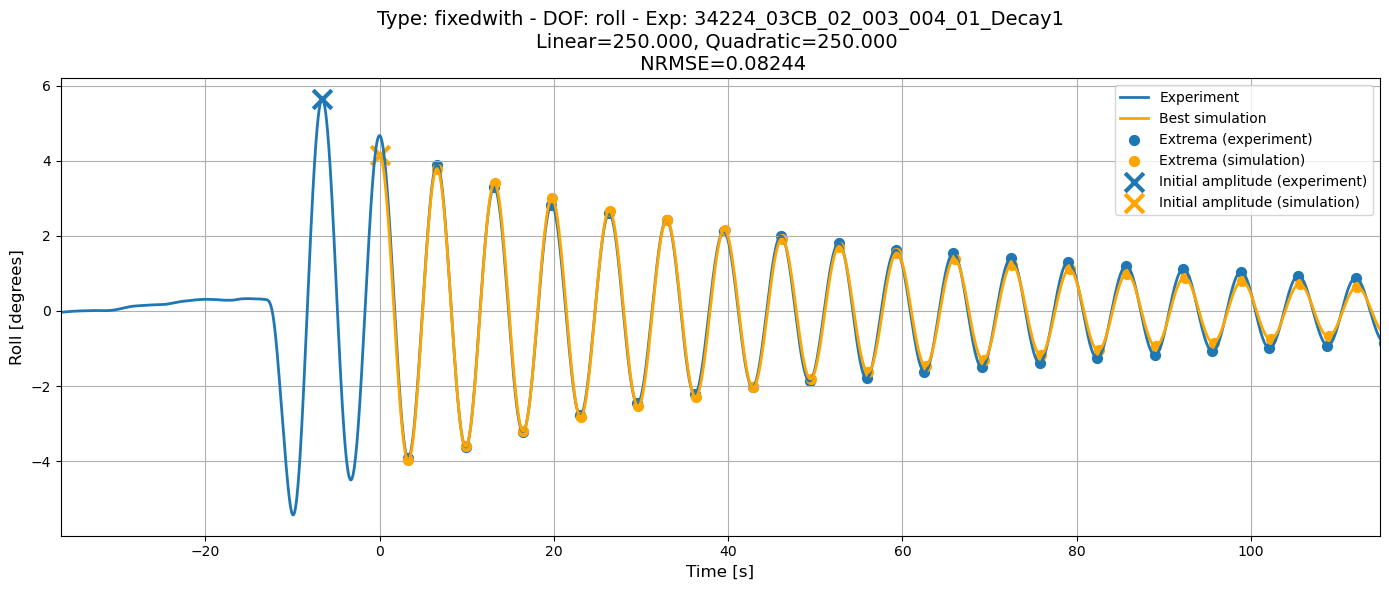

BEST -> lin=250.0000, quad=250.0000, score=0.082437

START: construction=fixedwithout, dof=heave, n=1

Experiment: 34224_03CB_02_004_010_01_Decay1.h5m
[coarse    1/49] lin=0.0000, quad=0.0000, score=0.449948 (peaks=0.466261, troughs=0.433634)
[coarse    2/49] lin=0.0000, quad=2.5000, score=0.267872 (peaks=0.229656, troughs=0.306087)
[coarse    3/49] lin=0.0000, quad=5.0000, score=0.515584 (peaks=0.474417, troughs=0.556751)
[coarse    4/49] lin=0.0000, quad=7.5000, score=0.648064 (peaks=0.606451, troughs=0.689677)
[coarse    5/49] lin=0.0000, quad=10.0000, score=0.731404 (peaks=0.689781, troughs=0.773027)
[coarse    6/49] lin=0.0000, quad=12.5000, score=0.788543 (peaks=0.747240, troughs=0.829846)
[coarse    7/49] lin=0.0000, quad=15.0000, score=0.830353 (peaks=0.789393, troughs=0.871313)
[coarse    8/49] lin=2.5000, quad=0.0000, score=0.087749 (peaks=0.040922, troughs=0.134575)
[coarse    9/49] lin=2.5000, quad=2.5000, score=0.460129 (peaks=0.414435, troughs=0.505823)
[coarse   10/49] l

KeyboardInterrupt: 

In [58]:
# ============================================================
# NOTEBOOK 10 - Alles runnen
# ============================================================
all_results = []
failed_cases = []

for construction, dof_dict in exp_paths.items():
    for dof, path_list in dof_dict.items():
        print("\n" + "=" * 80)
        print(f"START: construction={construction}, dof={dof}, n={len(path_list)}")
        print("=" * 80)

        for exp_path in path_list:
            print(f"\nExperiment: {exp_path.name}")

            try:
                exp_info = prepare_experiment(exp_path, dof)
                result = calibrate_single_experiment(exp_info, construction, dof, verbose=True)
                all_results.append(result)
                plot_best_fit(result, plots_dir)

                print(
                    f"BEST -> lin={result['best_lin']:.4f}, "
                    f"quad={result['best_quad']:.4f}, "
                    f"score={result['best_score']:.6f}"
                )

            except Exception as e:
                warnings.warn(f"Fout bij {exp_path}: {e}")
                failed_cases.append({
                    "construction": construction,
                    "dof": dof,
                    "exp_path": str(exp_path),
                    "error": str(e),
                })

print("\nKlaar.")
print(f"Aantal geslaagde calibraties: {len(all_results)}")
print(f"Aantal fouten: {len(failed_cases)}")


In [ ]:
# ============================================================
# NOTEBOOK 11 - Resultaten naar DataFrame
# ============================================================
results_rows = []
for r in all_results:
    results_rows.append({
        "construction": r["construction"],
        "dof": r["dof"],
        "exp_path": r["exp_path"],
        "file_name": Path(r["exp_path"]).name,
        "t_release": r["t_release"],
        "release_amplitude": r["a_release"],
        "t_init": r["t_init"],
        "initial_amplitude": r["a_init"],
        "extremum_type": r["extremum_type"],
        "sim_init_time": r["sim_init_time"],
        "sim_init_amplitude": r["sim_init_amp"],
        "linear_damping": r["best_lin"],
        "quadratic_damping": r["best_quad"],
        "score": r["best_score"],
        "nrmse_peaks": r["best_nrmse_peaks"],
        "nrmse_troughs": r["best_nrmse_troughs"],
    })

df_results = pd.DataFrame(results_rows)
df_failed = pd.DataFrame(failed_cases)

display(df_results.head())
if len(df_failed) > 0:
    display(df_failed.head())


,construction,dof,exp_path,file_name,t_release,release_amplitude,t_init,initial_amplitude,extremum_type,sim_init_time,sim_init_amplitude,linear_damping,quadratic_damping,score,nrmse_peaks,nrmse_troughs
0,spring,pitch,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,34224_03CB_02_002_001_01_Decay3.h5m,2335.460591,-7.544148,2342.721479,-6.065122,trough,6.1,-5.281804,300.0,300.0,0.040178,0.0329,0.047455


In [ ]:
# ============================================================
# NOTEBOOK 12 - Excel export per DOF
# ============================================================
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for dof in ["pitch", "roll", "heave"]:
        df_dof = df_results[df_results["dof"] == dof].copy()
        df_dof = df_dof.sort_values(["construction", "file_name"])
        df_dof.to_excel(writer, sheet_name=dof, index=False)

    if len(df_failed) > 0:
        df_failed.to_excel(writer, sheet_name="failed_cases", index=False)

print(f"Excel opgeslagen naar:\n{excel_path}")
print(f"Plots opgeslagen in:\n{plots_dir}")


Excel opgeslagen naar:
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs\calibrated_decay_coefficients.xlsx
Plots opgeslagen in:
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs\plots
